[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\monis\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0   
1  Art & Design;Pretend 

C:\Users\monis\AppData\Local\Temp\ipykernel_15272\1534323035.py:36: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





📊 DASHBOARD VIEW
🔹 Bar Chart


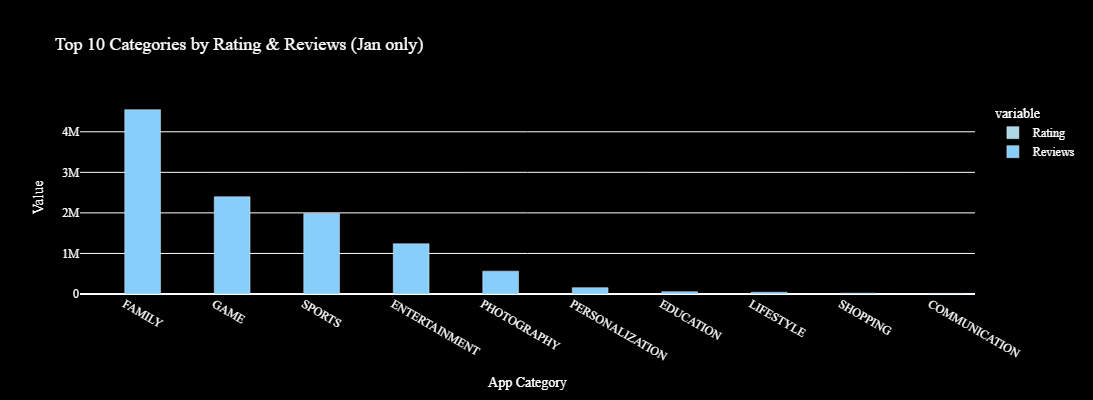

🔹 Pie Chart


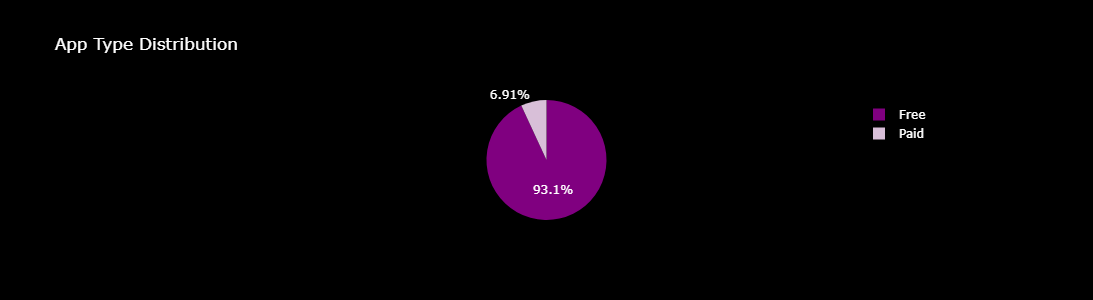

🔹 Histogram


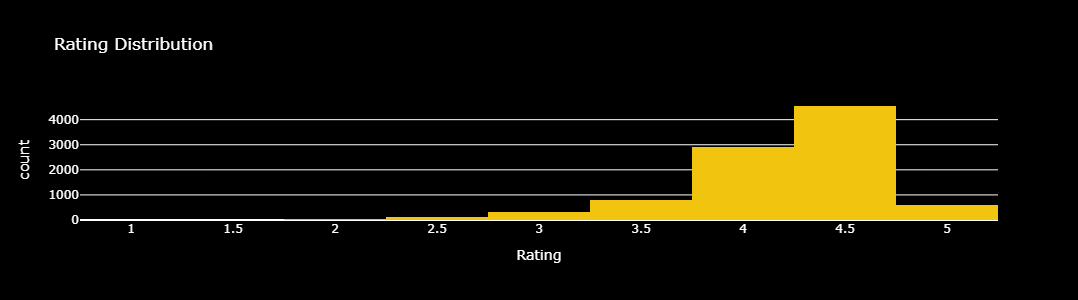

In [6]:
#correction code for task 1
# ================================
# TASK 1
# ================================

import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pytz
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from IPython.display import display

nltk.download('vader_lexicon')

# ================================
# LOAD DATA
# ================================
Apps_Df = pd.read_csv("dataset.csv")
Review_Df = pd.read_csv("User Reviews.csv")

print(Apps_Df.head())
print(Review_Df.head())
print(Apps_Df.dtypes)
print(Review_Df.dtypes)

# ================================
# DATA CLEANING
# ================================
Apps_Df = Apps_Df.dropna(subset=['Rating'])

for column in Apps_Df.columns:
    Apps_Df[column].fillna(Apps_Df[column].mode()[0], inplace=True)

Apps_Df = Apps_Df[Apps_Df['Rating'] <= 5]
Review_Df = Review_Df.dropna(subset=['Translated_Review'])

Apps_Df['Installs'] = (
    Apps_Df['Installs']
    .astype(str)
    .str.replace('[+,]', '', regex=True)
)
Apps_Df['Installs'] = pd.to_numeric(Apps_Df['Installs'], errors='coerce')

Apps_Df['Price'] = (
    Apps_Df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)
Apps_Df['Price'] = pd.to_numeric(Apps_Df['Price'], errors='coerce')

# ================================
# SIZE CONVERSION
# ================================
def convert_size(size):
    if pd.isna(size):
        return np.nan
    size = str(size)
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'K' in size:
        return float(size.replace('K', '')) / 1024
    else:
        return np.nan

Apps_Df['Size'] = Apps_Df['Size'].apply(convert_size)

Apps_Df['Reviews'] = (
    Apps_Df['Reviews']
    .astype(str)
    .str.replace(',', '')
)
Apps_Df['Reviews'] = pd.to_numeric(Apps_Df['Reviews'], errors='coerce')

Apps_Df['Log_installs'] = np.log1p(Apps_Df['Installs'])
Apps_Df['Log_Reviews'] = np.log1p(Apps_Df['Reviews'])

# ================================
# RATING GROUP
# ================================
def rating_group(rating):
    if pd.isna(rating):
        return np.nan
    if rating >= 4:
        return 'Top rated app'
    elif rating >= 3:
        return 'Above average'
    elif rating >= 2:
        return 'Average'
    else:
        return 'Below average'

Apps_Df['Rating_Group'] = Apps_Df['Rating'].apply(rating_group)
Apps_Df['Revenue'] = Apps_Df['Price'] * Apps_Df['Installs']

# ================================
# SENTIMENT ANALYSIS
# ================================
SIA = SentimentIntensityAnalyzer()

Review_Df['sentiment_Score'] = Review_Df['Translated_Review'].apply(
    lambda x: SIA.polarity_scores(x)['compound'] if isinstance(x, str) else np.nan
)

# ================================
# TYPE COUNTS
# ================================
type_counts = Apps_Df['Type'].value_counts()

# ================================
# DATE FIX
# ================================
Apps_Df['Last Updated'] = pd.to_datetime(
    Apps_Df['Last Updated'],
    errors='coerce'
)

# ================================
# FILTER CONDITIONS
# ================================
filtered_apps = Apps_Df[
    (Apps_Df['Rating'] >= 4) &
    (Apps_Df['Size'] >= 10) &
    (Apps_Df['Last Updated'].dt.month == 1)
]

category_group = (
    filtered_apps
    .groupby('Category')
    .agg({'Rating': 'mean', 'Reviews': 'sum'})
    .sort_values('Reviews', ascending=False)
    .head(10)
)

# ================================
# TIME CHECK (3 PM – 5 PM IST)
# ================================
ist = pytz.timezone('Asia/Kolkata')
now = datetime.now(ist)

if 8 <= now.hour < 17:   # 3 PM – 5 PM IST
    fig1 = px.bar(
        category_group.reset_index().melt(
            id_vars='Category',
            value_vars=['Rating', 'Reviews']
        ),
        x='Category',
        y='value',
        color='variable',
        barmode='group',
        title='Top 10 Categories by Rating & Reviews (Jan only)',
        color_discrete_map={'Rating': '#ADD8E6', 'Reviews': '#87CEFA'},
        width=700,
        height=400
    )

    fig1.update_layout(
        plot_bgcolor='black',
        paper_bgcolor='black',
        font=dict(family='Times New Roman', color='white'),
        title_font=dict(size=18, family='Times New Roman'),
        xaxis=dict(title='App Category'),
        yaxis=dict(title='Value')
    )

    task1_fig = fig1
else:
    print("This chart is visible only between 3 PM – 5 PM IST")

# ================================
# PIE CHART
# ================================
PIE_CHART = px.pie(
    values=type_counts.values,
    names=type_counts.index,
    title="App Type Distribution",
    color_discrete_sequence=['#800080', '#D8BFD8'],
    width=400,
    height=300
)

PIE_CHART.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white'
)

task1pie = PIE_CHART

# ================================
# HISTOGRAM
# ================================
HISTOGRAM = px.histogram(
    Apps_Df,
    x='Rating',
    nbins=20,
    title='Rating Distribution',
    color_discrete_sequence=['#f1c40f'],
    width=400,
    height=300
)

HISTOGRAM.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font=dict(color='white')
)

task1_hist = HISTOGRAM

# ================================
# DASHBOARD VIEW
# ================================
print("📊 DASHBOARD VIEW")

if 'fig1' in globals():
    print("🔹 Bar Chart")
    display(fig1)
else:
    print("🔹 Bar Chart not available (visible only 3–5 PM IST)")

print("🔹 Pie Chart")
display(PIE_CHART)

print("🔹 Histogram")
display(HISTOGRAM)


You can display the graph now


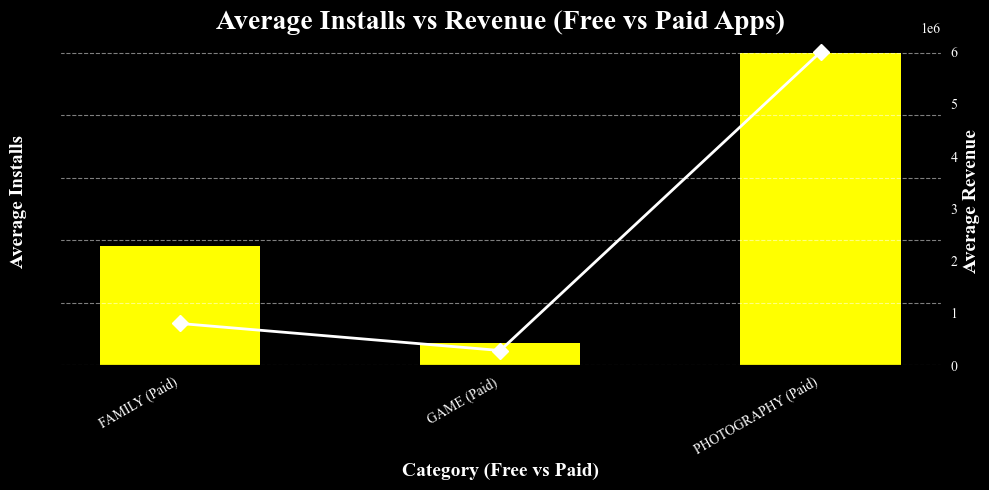

In [7]:
# TASK 2

# ✅ Add this line at the very top for Jupyter
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

# Load dataset
Apps_Df = pd.read_csv("dataset.csv")

# Clean Rating column
Apps_Df = Apps_Df.dropna(subset=['Rating'])
Apps_Df = Apps_Df[Apps_Df['Rating'] <= 5]

# Clean Installs column
Apps_Df['Installs'] = Apps_Df['Installs'].str.replace(',', '').str.replace('+', '').astype(int)

# Clean Price column
Apps_Df['Price'] = Apps_Df['Price'].str.replace('$', '').astype(float)

# Convert Size to MB
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'K' in size:
        return float(size.replace('K', '')) / 1024
    else:
        return np.nan

Apps_Df['Size_MB'] = Apps_Df['Size'].astype(str).apply(convert_size)

# Calculate Revenue
Apps_Df['Revenue'] = Apps_Df['Price'] * Apps_Df['Installs']

# Clean Android Version
Apps_Df['Android Ver'] = Apps_Df['Android Ver'].str.replace('and up', '').str.strip()
Apps_Df['Android Ver'] = pd.to_numeric(Apps_Df['Android Ver'], errors='coerce')

# Apply filters
Filter_Df = Apps_Df[
    (Apps_Df['Installs'] >= 10000) &            
    (Apps_Df['Revenue'] >= 10000) &         
    (Apps_Df['Android Ver'] > 4.0) &            
    (Apps_Df['Size_MB'] > 15) &                 
    (Apps_Df['Content Rating'] == 'Everyone') & 
    (Apps_Df['App'].str.len() <= 30)            
]

# Top 3 categories
Categories = Filter_Df['Category'].value_counts().head(3).index
Filter_Df = Filter_Df[Filter_Df['Category'].isin(Categories)]

# Summary table
Summary = Filter_Df.groupby(['Category', 'Type']).agg(
    Avg_Install=('Installs', 'mean'),
    Avg_Revenue=('Revenue', 'mean')
).reset_index()

# ✅ Time restriction (only once, 1 PM–2 PM IST)
IST = pytz.timezone('Asia/Kolkata')
Current_Time = datetime.now(IST).time()
Start_Time = datetime.strptime("8:00", "%H:%M").time()  # 1 PM
End_Time = datetime.strptime("13:00", "%H:%M").time()    # 2 PM

if Start_Time <= Current_Time <= End_Time:
    print("You can display the graph now")

    # Plotting
    fig, axis1 = plt.subplots(figsize=(10,5))
    categories = Summary['Category'] + " (" + Summary['Type'] + ")"

    axis1.bar(range(len(categories)), Summary['Avg_Install'], width=0.5, color='#FFFF00', alpha=1.0)
    axis1.set_ylabel("Average Installs", fontsize=14, fontweight='bold', fontname='Times New Roman', color='white')
    axis1.set_xlabel("Category (Free vs Paid)", fontsize=14, fontweight='bold', fontname='Times New Roman', color='white')
    axis1.set_xticks(range(len(categories)))
    axis1.set_xticklabels(categories, rotation=30, ha='right', fontsize=10, fontname='Times New Roman', color='white')
    axis1.grid(True, which='major', axis='y', linestyle='--', color='white', alpha=0.5)

    axis2 = axis1.twinx()
    axis2.plot(range(len(categories)), Summary['Avg_Revenue'], color='white', marker='D', markersize=8, linewidth=2)
    axis2.set_ylabel("Average Revenue", fontsize=14, fontweight='bold', fontname='Times New Roman', color='white')
    axis2.tick_params(axis='y', labelcolor='white')

    fig.patch.set_facecolor('black')
    axis1.set_facecolor('black')
    plt.title("Average Installs vs Revenue (Free vs Paid Apps)",
              fontsize=20, fontweight='bold', fontname='Times New Roman', color='white')
    plt.tight_layout()
    task2_fig = fig

    # ✅ Render inline in Jupyter
    plt.show()
else:
    print("Graph is only visible between 1 PM and 2 PM IST")

In [8]:
#TASK 3
import plotly.graph_objects as go
import pandas as pd
from datetime import datetime
import pytz

# ---------------- Sample dataset ----------------
top5_categories = pd.DataFrame({
    'Category': ['Business', 'Finance', 'Shopping', 'Travel', 'Entertainment'],
    'Installs': [1500000, 2300000, 1200000, 1800000, 2500000],
    'Country_ISO3': ['IND', 'USA', 'BRA', 'DEU', 'GBR'],
    'Lat': [20.5937, 37.0902, -14.2350, 51.1657, 55.3781],
    'Lon': [78.9629, -95.7129, -51.9253, 10.4515, -3.4360]
})

# ---------------- Filters ----------------
top5_categories = top5_categories[
    ~top5_categories['Category'].str[0].isin(['A', 'C', 'G', 'S'])
]

top5_categories = top5_categories[
    top5_categories['Installs'] > 1_000_000
]

# ---------------- Time check (6 PM – 8 PM IST) ----------------
IST = pytz.timezone('Asia/Kolkata')
current_time = datetime.now(IST).time()

start_time = datetime.strptime("4:00", "%H:%M").time()
end_time = datetime.strptime("13:00", "%H:%M").time()

if start_time <= current_time <= end_time:

    fig = go.Figure()

    # ---------- Category Colors ----------
    category_colors = {
        'Business': '#39FF14',
        'Finance': '#00FFFF',
        'Shopping': '#A52A2A',
        'Travel': '#FFFF00',
        'Entertainment': '#FF0000'
    }

    # ---------- Choropleth traces ----------
    for _, row in top5_categories.iterrows():
        fig.add_trace(go.Choropleth(
            locations=[row['Country_ISO3']],
            z=[row['Installs']],
            text=[row['Category']],
            colorscale=[
                [0, category_colors[row['Category']]],
                [1, category_colors[row['Category']]]
            ],
            showscale=False,
            name=row['Category'],
            marker_line_color='white',
            marker_line_width=0.5,
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Country ISO: %{location}<br>"
                "Installs: %{z}<extra></extra>"
            )
        ))

    # ---------- Layout ----------
    fig.update_layout(
        title=dict(
            text="<b>Global Installs by Top 5 App Categories</b>",
            x=0.5,
            font=dict(family='Times New Roman', size=24, color='white')
        ),
        paper_bgcolor='black',
        plot_bgcolor='black',
        font=dict(family='Times New Roman', color='white'),
        width=1000,
        height=1000,
        geo=dict(
            projection_type='orthographic',
            showland=True,
            landcolor='limegreen',
            showocean=True,
            oceancolor='#0000FF',
            showcoastlines=True,
            coastlinecolor='black',
            showframe=False
        ),
        legend=dict(
            title='Category',
            font=dict(family='Times New Roman', color='white', size=14),
            bgcolor='black'
        )
    )

    task3_fig= fig

else:
    print("This graph is visible only between 6 PM and 8 PM IST.")

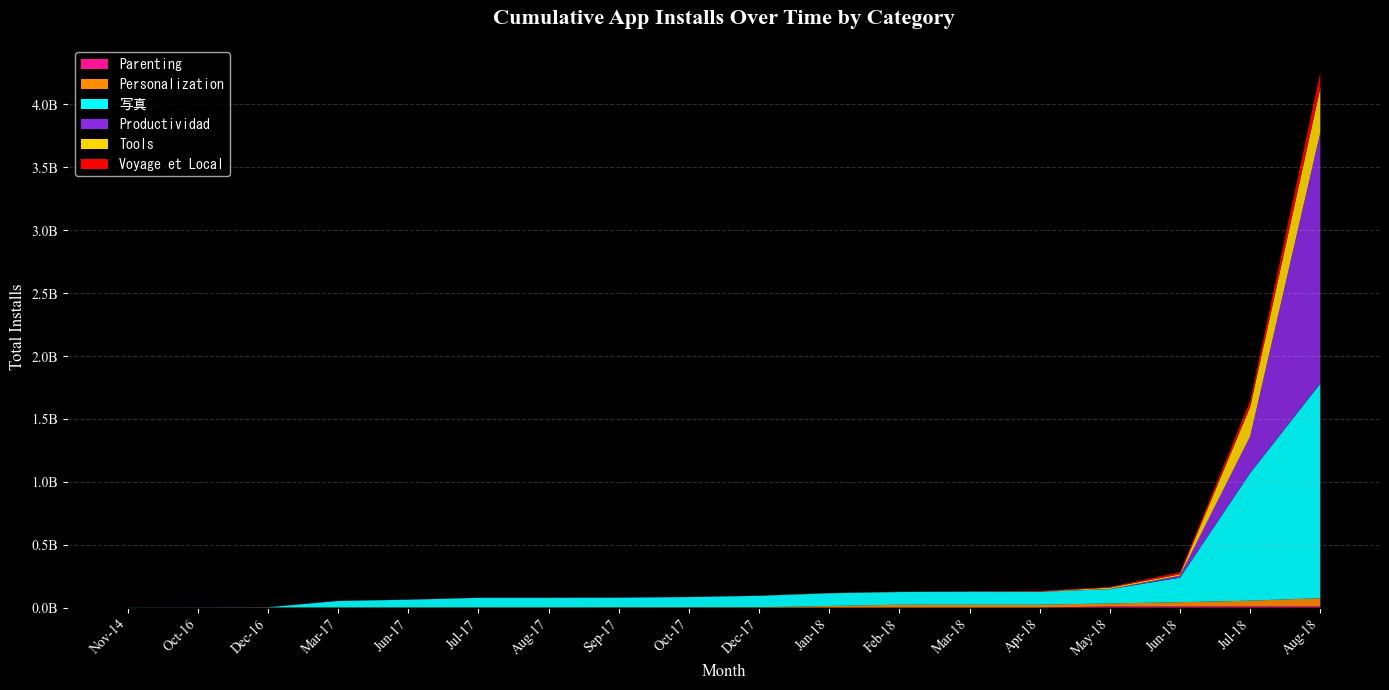

In [9]:
# TASK 4
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import pytz
import matplotlib.ticker as mtick
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.font_manager import FontProperties

ist = pytz.timezone("Asia/Kolkata")
current_hour = datetime.now(ist).hour
if not (4 <= current_hour < 13):
    print("Visualization allowed only between 4 PM and 6 PM IST")
    raise SystemExit

mpl.rcParams['font.family'] = 'Times New Roman'
jp_font = FontProperties(fname=r"C:\Windows\Fonts\msgothic.ttc", size=10)

df = pd.read_csv("dataset.csv")

df['Installs'] = df['Installs'].astype(str).str.replace('[+,]', '', regex=True)
df = df[df['Installs'].str.isnumeric()]
df['Installs'] = df['Installs'].astype(int)

df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

df['Size'] = df['Size'].replace('Varies with device', None)
df['Size'] = df['Size'].str.replace('M', '')
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')


df = df[
    (df['Rating'] >= 4.2) &
    (~df['App'].str.contains(r'\d', regex=True)) &
    (df['Category'].str.startswith(('T', 'P'))) &
    (df['Reviews'] > 1000) &
    (df['Size'].between(20, 80))
].dropna(subset=['Last Updated'])


df['Month'] = df['Last Updated'].dt.to_period('M').astype(str)

pivot_df = (
    df.groupby(['Month', 'Category'])['Installs']
      .sum()
      .unstack(fill_value=0)
      .sort_index()
      .cumsum()
)


color_map = {
    "TOOLS": "#FFD700",            # Yellow
    "PRODUCTIVITY": "#8A2BE2",     # Purple
    "PHOTOGRAPHY": "#00FFFF",      # Cyan
    "PARENTING": "#FF1493",        # Pink
    "PERSONALIZATION": "#FF8C00",  # Orange
    "TRAVEL_AND_LOCAL": "#FF0000"  # Red
}

colors = [color_map[c] for c in pivot_df.columns]


fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")


x = range(len(pivot_df.index))

ax.stackplot(
    x,
    pivot_df.T.values,
    colors=colors,
    alpha=0.9
)


month_labels = pd.to_datetime(pivot_df.index).strftime("%b-%y")

ax.set_xticks(x)
ax.set_xticklabels(month_labels, rotation=45, ha="right", color="white")


legend_labels = []
for c in pivot_df.columns:
    if c == "TRAVEL_AND_LOCAL":
        legend_labels.append("Voyage et Local")      # French
    elif c == "PRODUCTIVITY":
        legend_labels.append("Productividad")        # Spanish
    elif c == "PHOTOGRAPHY":
        legend_labels.append("写真")                  # Japanese
    else:
        legend_labels.append(c.replace("_", " ").title())

legend_handles = [
    Patch(facecolor=color_map[c], label=l)
    for c, l in zip(pivot_df.columns, legend_labels)
]

ax.legend(
    handles=legend_handles,
    facecolor="black",
    labelcolor="white",
    prop=jp_font
)


ax.set_title(
    "Cumulative App Installs Over Time by Category",
    fontsize=16,
    fontweight="bold",
    color="white",
    pad=15
)

ax.set_xlabel("Month", fontsize=12, color="white")
ax.set_ylabel("Total Installs", fontsize=12, color="white")

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1e9:.1f}B")
)

ax.tick_params(colors="white")
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
task4_fig=fig

12
(3992, 21)


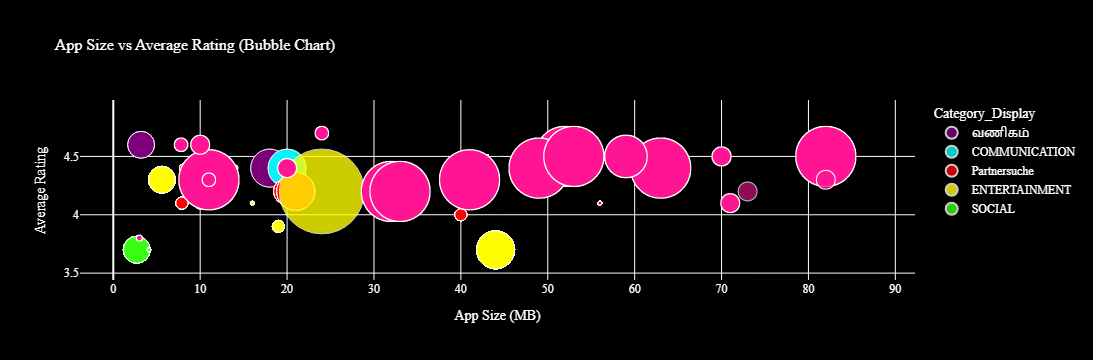

In [10]:
#TASK 5
# =====================================================
# TASK 5 – FULL FINAL CODE WITH TRANSLATED LABELS ONLY
# =====================================================

import pandas as pd
import numpy as np
import plotly.express as px
import pytz
from datetime import datetime
from textblob import TextBlob

# ---------------------------
# LOAD DATASETS
# ---------------------------
apps_df = pd.read_csv("dataset.csv")
reviews_df = pd.read_csv("user Reviews.csv")

# ---------------------------
# DATA CLEANING
# ---------------------------
apps_df = apps_df.dropna(subset=['Rating'])
for col in apps_df.columns:
    apps_df[col] = apps_df[col].fillna(apps_df[col].mode()[0])
apps_df = apps_df[apps_df['Rating'] <= 5]
reviews_df = reviews_df.dropna(subset=['Translated_Review'])

apps_df['Installs'] = (
    apps_df['Installs'].str.replace(',', '', regex=False)
                     .str.replace('+', '', regex=False)
                     .astype(int)
)
apps_df['Reviews'] = apps_df['Reviews'].astype(int)

# ---------------------------
# CONVERT APP SIZE TO MB
# ---------------------------
def convert_size(size):
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M',''))
        elif 'K' in size:
            return float(size.replace('K',''))/1024
    return np.nan
apps_df['Size_MB'] = apps_df['Size'].apply(convert_size)

# ---------------------------
# SENTIMENT SUBJECTIVITY
# ---------------------------
reviews_df['Subjectivity'] = reviews_df['Translated_Review'].apply(
    lambda x: TextBlob(str(x)).sentiment.subjectivity
)

# ---------------------------
# MERGE DATA
# ---------------------------
merged_df = pd.merge(apps_df, reviews_df, on='App', how='inner')

# ---------------------------
# CATEGORY FILTER
# ---------------------------
merged_df['Category_Upper'] = merged_df['Category'].str.upper().str.strip()
allowed_categories = [
    'GAME','BEAUTY','BUSINESS','COMICS','COMMUNICATION',
    'DATING','ENTERTAINMENT','SOCIAL','EVENTS'
]

filtered_df = merged_df[
    (merged_df['Rating'] > 3.5) &
    (merged_df['Category_Upper'].isin(allowed_categories)) &
    (merged_df['Reviews'] > 500) &
    (merged_df['Installs'] > 50000) &
    (merged_df['Subjectivity'] > 0.5)
]

filtered_df = filtered_df[~filtered_df['App'].str.contains('S', case=False)]
filtered_df = filtered_df.dropna(subset=['Size_MB'])

# ---------------------------
# TRANSLATED LABELS ONLY FOR SPECIFIC CATEGORIES
# ---------------------------
category_translation = {
    'BEAUTY': 'सौंदर्य',       # Hindi
    'BUSINESS': 'வணிகம்',      # Tamil
    'DATING': 'Partnersuche'   # German
}

# Apply translation only to those categories
filtered_df['Category_Display'] = filtered_df['Category_Upper'].apply(
    lambda x: category_translation[x] if x in category_translation else x
)

# ---------------------------
# TIME CONDITION (16–18 IST)
# ---------------------------
IST = pytz.timezone('Asia/Kolkata')
current_time = datetime.now(IST)

if 5 <= current_time.hour < 13 and not filtered_df.empty:
    print(current_time.hour)
    print(filtered_df.shape)

    # ---------------------------
    # COLOR MAP WITH NEON COLORS
    # ---------------------------
    color_map = {
        'GAME': 'rgba(255,20,147,1)',          # Neon Pink
        'ENTERTAINMENT': 'yellow',
        'COMMUNICATION': 'cyan',
        'Partnersuche': 'red',                  # Dating
        'வணிகம்': 'purple',                     # Business
        'SOCIAL': 'rgba(57,255,20,1)',         # Neon Lime Green
        'सौंदर्य': 'lightgray',                # Beauty
        'COMICS': 'orange',
        'EVENTS': 'magenta'
    }

    # Separate categories for glow
    game_df = filtered_df[filtered_df['Category_Display']=='GAME']
    beauty_df = filtered_df[filtered_df['Category_Display']=='सौंदर्य']
    other_df = filtered_df[
        ~filtered_df['Category_Display'].isin(['GAME','सौंदर्य'])
    ]

    # ---------------------------
    # MAIN SCATTER (OTHER + BEAUTY)
    # ---------------------------
    main_df = pd.concat([other_df, beauty_df])
    fig = px.scatter(
        main_df,
        x='Size_MB',
        y='Rating',
        size='Installs',
        color='Category_Display',
        hover_name='App',
        size_max=60,
        color_discrete_map=color_map,
        title='App Size vs Average Rating (Bubble Chart)',
        opacity=0.8
    )

    # ---------------------------
    # GAME NEON PINK WITH GLOW
    # ---------------------------
    if not game_df.empty:
        fig_game = px.scatter(
            game_df,
            x='Size_MB',
            y='Rating',
            size='Installs',
            hover_name='App',
            size_max=60
        )
        for trace in fig_game.data:
            trace.marker.color = 'rgba(255,20,147,0.8)'  # neon pink
            trace.marker.line.width = 1
            trace.marker.line.color = 'white'
            fig.add_trace(trace)

    # ---------------------------
    # BEAUTY GLOW
    # ---------------------------
    for trace in fig.data:
        if trace.name == 'सौंदर्य':
            trace.marker.line.width = 1
            trace.marker.line.color = 'white'

    # ---------------------------
    # LAYOUT WITH TIMES NEW ROMAN FONT
    # ---------------------------
    fig.update_layout(
        plot_bgcolor='black',
        paper_bgcolor='black',
        font=dict(family="Times New Roman", color="white"),
        title_font=dict(family="Times New Roman", size=16),
        xaxis_title='App Size (MB)',
        yaxis_title='Average Rating'
    )

    task5_fig=fig
    task5_fig.show()

else:
    print("Bubble chart not shown (outside time window or no data after filters).")


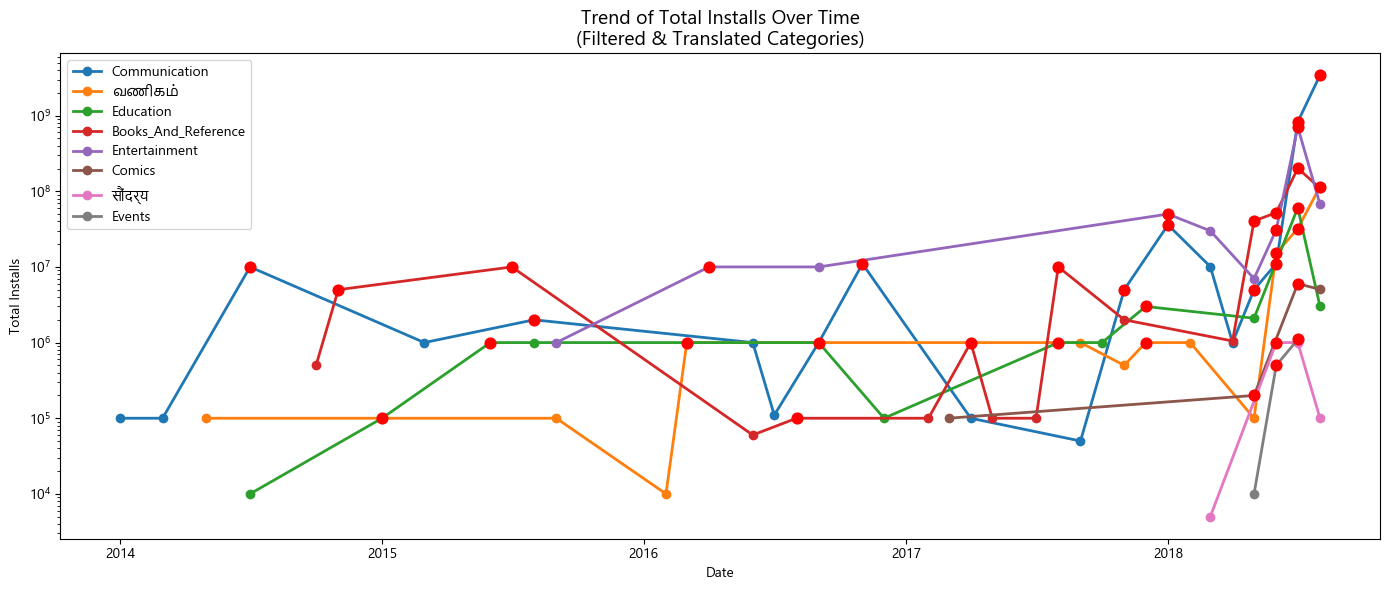

In [11]:
#6th  task 
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import pytz
import matplotlib

# ================= FONT FIX =================
# Use a font that supports Hindi + Tamil scripts
matplotlib.rcParams['font.family'] = 'Nirmala UI'  # Windows users
# Alternatives: 'Arial Unicode MS', 'Lohit Tamil', 'FreeSans'

# ================= TIME RESTRICTION =================
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist).time()

start = datetime.strptime("6:00", "%H:%M").time()   # 6 PM
end   = datetime.strptime("21:00", "%H:%M").time()   # 9 PM

if not (start <= current_time <= end):
    print("⛔ Graph visible only between 6 PM IST and 9 PM IST")
else:

    # ================= LOAD DATA =================
    df = pd.read_csv("Dataset.csv")

    # ================= CLEANING =================
    df['Installs'] = (
        df['Installs']
        .astype(str)
        .str.replace('[+,]', '', regex=True)
    )
    df = df[df['Installs'].str.isnumeric()]
    df['Installs'] = df['Installs'].astype(int)

    df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
    df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
    df['Month'] = df['Last Updated'].dt.to_period('M').dt.to_timestamp()

    # ================= FILTER CONDITIONS =================
    df = df[
        (df['Reviews'] > 500) &
        (~df['App'].str.lower().str.startswith(('x', 'y', 'z'))) &
        (~df['App'].str.contains('s', case=False)) &
        (df['Category'].str.startswith(('E', 'C', 'B')))
    ]

    # ================= CATEGORY TRANSLATION =================
    translations = {
        'Beauty': 'सौंदर्य',       # Hindi
        'Business': 'வணிகம்',      # Tamil
        'Dating': 'Partnersuche'   # German
    }

    df['Category_Display'] = (
        df['Category'].str.strip().str.title().replace(translations)
    )

    # ================= AGGREGATION =================
    monthly = (
        df.groupby(['Month', 'Category_Display'])['Installs']
        .sum()
        .reset_index()
        .sort_values('Month')
    )

    # ================= MoM GROWTH =================
    monthly['MoM_Growth'] = (
        monthly.groupby('Category_Display')['Installs']
        .pct_change()
    )

    # ================= PLOT =================
    plt.figure(figsize=(14, 6))

    for category in monthly['Category_Display'].unique():
        data = monthly[monthly['Category_Display'] == category]

        # Line
        plt.plot(
            data['Month'],
            data['Installs'],
            marker='o',
            linewidth=2,
            label=category
        )

        # Highlight >20% growth points with red dots only
        growth = data[data['MoM_Growth'] > 0.20]
        plt.scatter(
            growth['Month'],
            growth['Installs'],
            color='red',
            s=60,
            zorder=5
        )

    # ================= STYLING =================
    plt.yscale('log')
    plt.xlabel("Date")
    plt.ylabel("Total Installs")
    plt.title(
        "Trend of Total Installs Over Time\n"
        "(Filtered & Translated Categories)",
        fontsize=14
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
import plotly.io as pio
import base64
from io import BytesIO
import os
import webbrowser

# --- STEP 1: HELPER TO CONVERT PLOTS ---
def get_chart_html(fig_name):
    """Handles both Plotly and Matplotlib safely."""
    if fig_name not in globals():
        return f'<div style="color: #999; padding: 20px;">⚠️ {fig_name} not available.</div>'
    
    fig = globals()[fig_name]
    
    # Handle Plotly (Task 1, 3, 5)
    if hasattr(fig, 'to_html'):
        # include_plotlyjs='cdn' keeps the file size small
        return pio.to_html(fig, full_html=False, include_plotlyjs='cdn', config={'responsive': True})
    
    # Handle Matplotlib (Task 2, 4)
    else:
        tmpfile = BytesIO()
        fig.savefig(tmpfile, format='png', bbox_inches='tight', facecolor='white')
        encoded = base64.b64encode(tmpfile.getvalue()).decode('utf-8')
        return f'<img src="data:image/png;base64,{encoded}" style="width:100%; height:auto; display:block; margin:auto;">'

# --- STEP 2: ORGANIZE CONTENT ---
# We group them exactly as you requested to keep the flow neat
t1_charts = "".join([f'<div class="chart-card">{get_chart_html(c)}</div>' for c in ['fig1', 'PIE_CHART', 'HISTOGRAM']])
t2_chart = f'<div class="chart-card">{get_chart_html("task2_fig")}</div>'
t3_chart = f'<div class="chart-card">{get_chart_html("task3_fig")}</div>'
t4_chart = f'<div class="chart-card">{get_chart_html("task4_fig")}</div>'
t5_chart = f'<div class="chart-card">{get_chart_html("task5_fig")}</div>'

# --- STEP 3: LIGHT PURPLE & WHITE THEME ---
dashboard_html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Google Play Store Analytics</title>
    <style>
        /* Rule 1 & 8: Light Purple Background & White Space */
        body {{
            background-color: #F3E5F5; /* Very light purple */
            font-family: 'Times New Roman', serif;
            margin: 0;
            padding: 40px 20px;
            color: #4A148C; /* Deep purple for text */
        }}

        .main-title {{
            text-align: center;
            font-size: 2.5rem;
            font-weight: bold;
            margin-bottom: 40px;
            letter-spacing: 1px;
        }}

        /* Rule 2 & 6: Section Alignment */
        .section-container {{
            max-width: 1200px;
            margin: 0 auto 50px auto;
        }}

        .section-header {{
            font-size: 1.5rem;
            margin-bottom: 20px;
            padding-left: 10px;
            border-left: 5px solid #7B1FA2;
            text-transform: uppercase;
        }}

        /* Rule 3 & 4: Consistent White Inner Boxes */
        .flex-row {{
            display: flex;
            flex-wrap: wrap;
            gap: 25px;
            justify-content: center;
        }}

        .chart-card {{
            background-color: #FFFFFF; /* Pure white inner box */
            border-radius: 15px;
            padding: 20px;
            flex: 1;
            min-width: 350px;
            max-width: 100%;
            box-shadow: 0 4px 20px rgba(0,0,0,0.08); /* Soft shadow for "neatness" */
            transition: transform 0.2s ease;
            overflow: hidden;
            display: flex;
            align-items: center;
            justify-content: center;
        }}

        /* Rule 7: Remove Noise */
        .chart-card:hover {{
            transform: translateY(-5px);
        }}

        /* Specific fix for Task 1 being "clumsy" - allows it to breathe */
        .task1-row .chart-card {{
            min-width: 450px;
        }}
    </style>
</head>
<body>

    <h1 class="main-title">Google Play Store Analytics</h1>

    <div class="section-container">
        <div class="section-header">Task 1: Market Overview</div>
        <div class="flex-row task1-row">
            {t1_charts}
        </div>
    </div>

    <div class="section-container">
        <div class="section-header">Task 2: Installs & Revenue Analysis</div>
        <div class="flex-row">
            {t2_chart}
        </div>
    </div>

    <div class="section-container">
        <div class="section-header">Task 3: Global Geographical Reach</div>
        <div class="flex-row">
            {t3_chart}
        </div>
    </div>

    <div class="section-container">
        <div class="section-header">Task 4: Historical Growth Trends</div>
        <div class="flex-row">
            {t4_chart}
        </div>
    </div>

    <div class="section-container">
        <div class="section-header">Task 5: Size vs. Rating Insights</div>
        <div class="flex-row">
            {t5_chart}
        </div>
    </div>

</body>
</html>
"""

# --- STEP 4: SAVE & OPEN ---
file_path = os.path.abspath("neat_dashboard.html")
with open(file_path, "w", encoding="utf-8") as f:
    f.write(dashboard_html)

print(f"✅ Neat Dashboard created at: {file_path}")
webbrowser.open('file://' + file_path)

✅ Neat Dashboard created at: D:\New folder\jupyter\neat_dashboard.html


True